# DM - Analyse de Survie
## Master MIAGE M1 - Data Science et Applications

Objectif : Analyser la survie des patients avec les variables clés comme l'âge, le sexe, le statut de fumeur, les comorbidités, le traitement, l'activité physique et l'IMC.


## 1. Installation et importation des bibliothèques

In [ ]:
# Installation de lifelines si nécessaire
# !pip install lifelines --break-system-packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import plot_lifetimes

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 2. Lecture et exploration des données

In [ ]:
# Lecture du fichier CSV
df = pd.read_csv('/content/survival_data_1000.csv')

print("Shape des données:", df.shape)
df.head(10)

Shape des données: (1000, 9)


,Age,Sex,Smoker,Comorbidities,Treatment,BMI,Physical_Activity,Time_to_Event,Event_Observed
0,73,Female,0,0,Standard,23,Moderate,63.839174,0
1,55,Male,1,1,Standard,20,Moderate,67.477398,1
2,60,Female,0,1,Standard,30,Moderate,79.181521,1
3,56,Male,0,1,Standard,28,Low,14.761940,1
4,72,Female,0,1,Standard,37,High,17.227929,1
5,70,Female,1,1,Experimental,29,Low,15.873675,0
6,64,Female,0,1,Standard,21,High,63.980305,1
7,48,Female,0,1,Standard,20,Low,197.308730,1
8,52,Female,1,2,Standard,22,Moderate,3.433285,0
9,49,Male,0,2,Standard,21,Low,1.611551,1


In [ ]:
# Informations sur les valeurs manquantes
print("Valeurs manquantes :")
print(df.isnull().sum())

Valeurs manquantes :
Age                  0
Sex                  0
Smoker               0
Comorbidities        0
Treatment            0
BMI                  0
Physical_Activity    0
Time_to_Event        0
Event_Observed       0
dtype: int64


Il n'y a pas de valeurs manquantes dans le jeu de données.

## 3. Transformation des variables

Création des tranches d'âge et d'IMC (BMI).

In [ ]:
# Création de la variable Tranche_Age (<50, 50-60, >60)
def categorize_age(age):
    if age < 50:
        return '<50'
    elif age <= 60:
        return '50-60'
    else:
        return '>60'

df['Tranche_Age'] = df['Age'].apply(categorize_age)

# Création de la variable Tranche_BMI (<18, 18-26, >26)
def categorize_bmi(bmi):
    if bmi < 18:
        return '<18'
    elif bmi <= 26:
        return '18-26'
    else:
        return '>26'

df['Tranche_BMI'] = df['BMI'].apply(categorize_bmi)

print("\nDistribution des tranches d'âge:")
print(df['Tranche_Age'].value_counts().sort_index())
print("\nDistribution des tranches d'IMC:")
print(df['Tranche_BMI'].value_counts().sort_index())


Distribution des tranches d'âge:
Tranche_Age
50-60    402
<50      152
>60      446
Name: count, dtype: int64

Distribution des tranches d'IMC:
Tranche_BMI
18-26    557
<18       93
>26      350
Name: count, dtype: int64


Nous avons créé des variables catégorielles Tranche_Age et Tranche_BMI à partir des variables quantitatives Age et BMI, afin de faciliter l’analyse descriptive et l’interprétation des courbes de survie.

## 4. Statistiques descriptives sur la variable "Time_to_Event"

Statistiques descriptives sur Time_to_Event:
count    1000.000000
mean       42.420523
std        53.967320
min         0.051313
25%         9.722772
50%        23.819866
75%        52.941360
max       457.199295
Name: Time_to_Event, dtype: float64


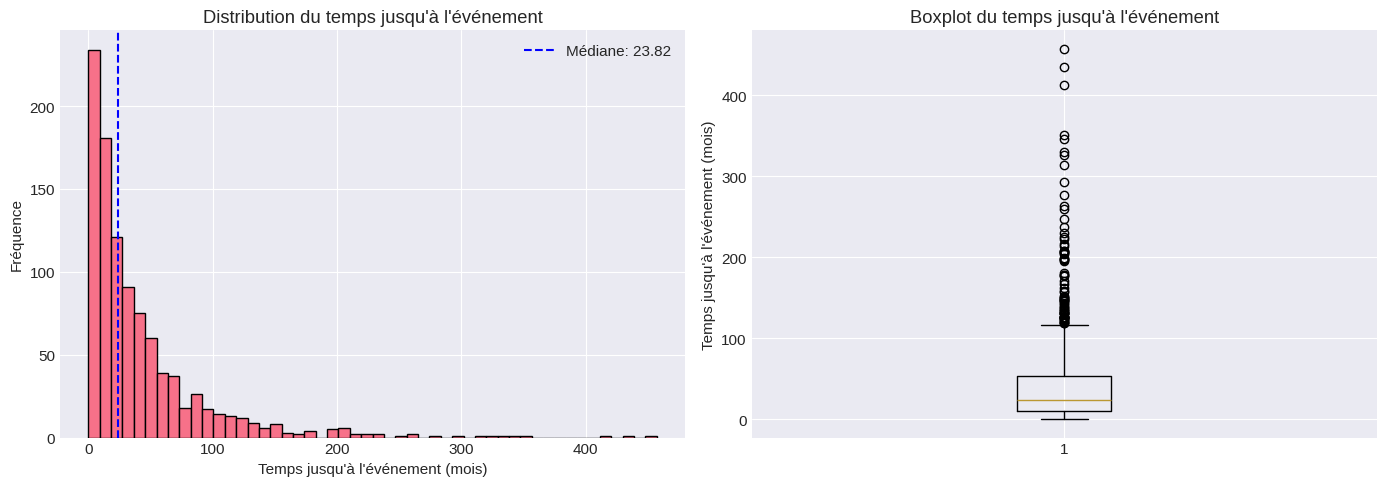

In [ ]:
print("Statistiques descriptives sur Time_to_Event:")
print(df['Time_to_Event'].describe())

# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Time_to_Event'], bins=50, edgecolor='black')
axes[0].set_xlabel('Temps jusqu\'à l\'événement (mois)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution du temps jusqu\'à l\'événement')
axes[0].axvline(df['Time_to_Event'].median(), color='blue', linestyle='--', label=f'Médiane: {df["Time_to_Event"].median():.2f}')
axes[0].legend()

axes[1].boxplot(df['Time_to_Event'], vert=True)
axes[1].set_ylabel('Temps jusqu\'à l\'événement (mois)')
axes[1].set_title('Boxplot du temps jusqu\'à l\'événement')

plt.tight_layout()
plt.show()

L’histogramme montre la distribution du temps jusqu’à l’événement (en mois) pour l’ensemble des patients.
- La majorité des observations se situe dans les premiers mois (entre 0 et environ 50).
- La médiane est d’environ 23,8 mois.

Beaucoup de patients ont un temps de suivi court et quelques patients ont des durées très longues (jusqu’à plus de 400 mois soit 33 ans).

Le boxplot permet d’observer la dispersion et les valeurs extrêmes :
- La médiane se situe autour de 24 mois, ce qui confirme les résultats.
- La majorité des données est concentrée entre environ 0 à 60 mois.
- On remarque qu'il y a beaucoup d'outliers au-delà de 100, et même jusqu’à 450 mois.

Ces valeurs élevées correspondent probablement à des patients censurés, qui n’ont pas présenté l’événement (le décès) pendant la période d’observation.

## 5. Analyse des variables qualitatives et quantitatives

In [ ]:
qualitative_vars = ['Sex', 'Smoker', 'Treatment', 'Physical_Activity', 'Event_Observed']

for var in qualitative_vars:
    if var == 'Smoker':
        counts = df[var].value_counts().rename({0: 'Non-smoker', 1: 'Smoker'})
    elif var == 'Event_Observed':
        counts = df[var].value_counts().rename({1: 'Deceased', 0: 'Censored'})
    else:
        counts = df[var].value_counts()
    print(counts)
    print("\n")

Sex
Male      506
Female    494
Name: count, dtype: int64


Smoker
Non-smoker    612
Smoker        388
Name: count, dtype: int64


Treatment
Standard        726
Experimental    274
Name: count, dtype: int64


Physical_Activity
Moderate    490
Low         293
High        217
Name: count, dtype: int64


Event_Observed
Deceased    711
Censored    289
Name: count, dtype: int64




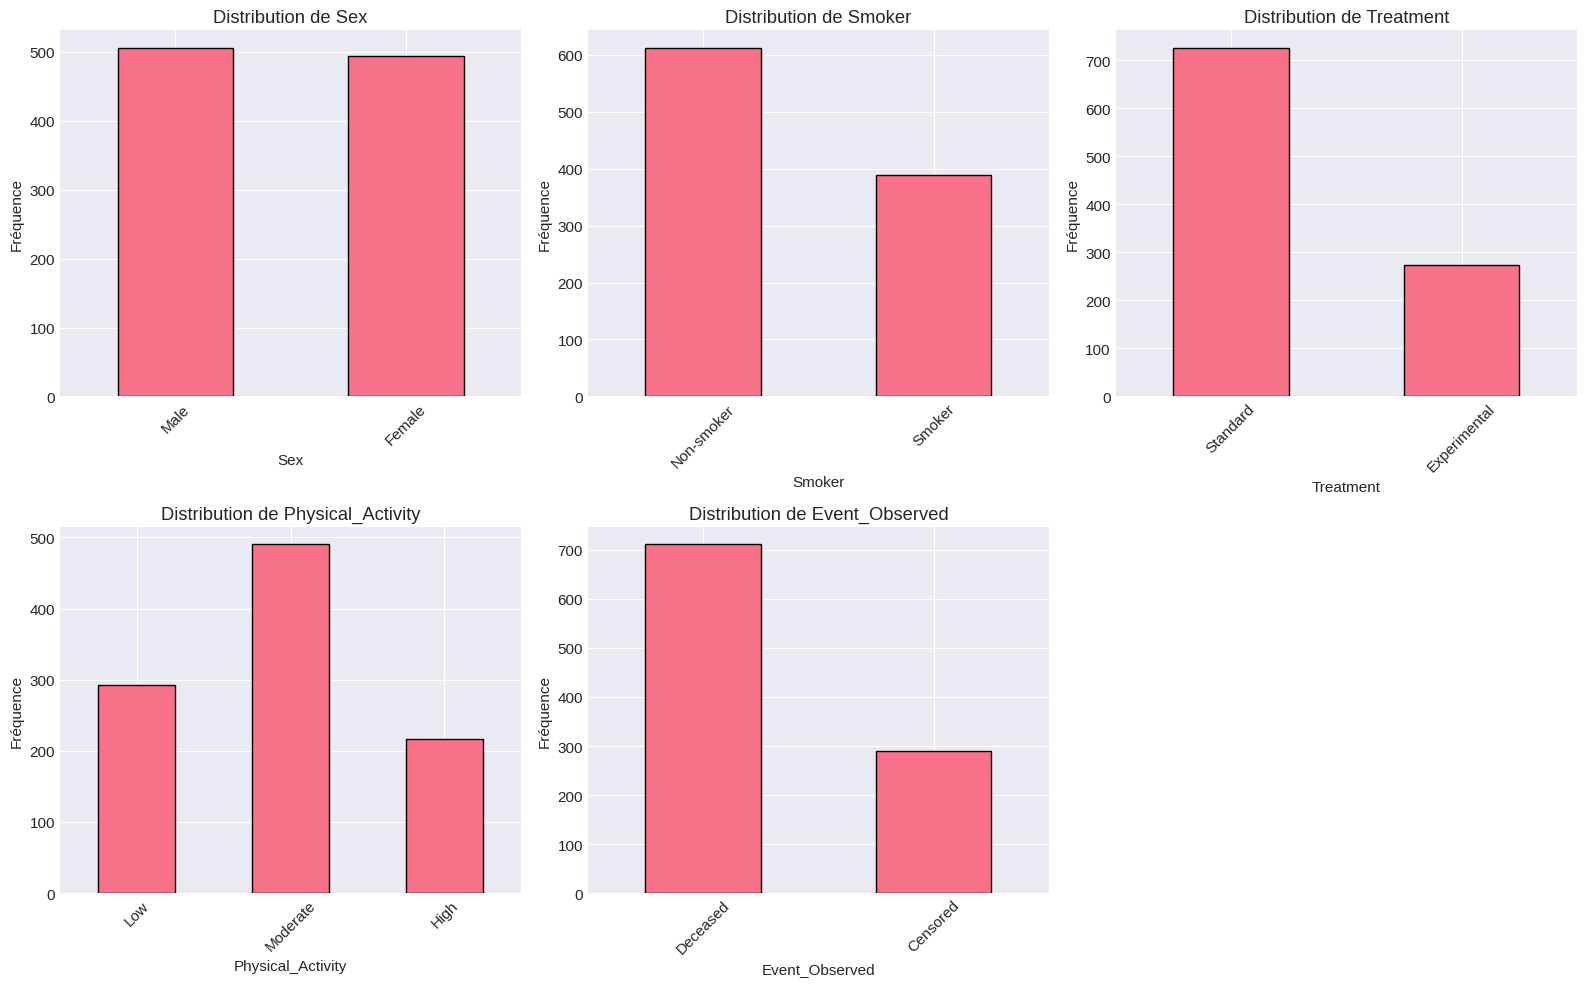

In [ ]:
# Visualisation des variables qualitatives
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, var in enumerate(qualitative_vars):
  if var == 'Smoker':
      df[var].value_counts().rename(
          {0: 'Non-smoker', 1: 'Smoker'}
      ).plot(kind='bar', edgecolor='black', ax=axes[i])

  elif var == 'Event_Observed':
      df[var].value_counts().rename(
          {0: 'Censored', 1: 'Deceased'}
      ).plot(kind='bar', edgecolor='black', ax=axes[i])

  elif var == 'Physical_Activity':
        order = ['Low', 'Moderate', 'High']
        df[var].value_counts().reindex(order).plot(kind='bar', edgecolor='black', ax=axes[i])

  else :
        df[var].value_counts().plot(kind='bar', edgecolor='black', ax=axes[i])

  axes[i].set_title(f'Distribution de {var}')
  axes[i].set_xlabel(var)
  axes[i].set_ylabel('Fréquence')
  axes[i].tick_params(axis='x', rotation=45)

axes[5].axis('off')
plt.tight_layout()
plt.show()

Les graphiques de distribution montrent que la répartition du sexe des patients est équilibrée, qu'il y a une majorité de non-fumeurs, et qu'une grande majorité des patients ont un traitement standard. La plupart des patients ont une activité physique modérée. Le nombre de décès observés est supérieur au nombre de patients censurés, ce qui permet d'avoir une bonne base pour l’analyse de survie.

In [ ]:
# Variables quantitatives
quantitative_vars = ['Age', 'Comorbidities', 'BMI']
print(df[quantitative_vars].describe())

               Age  Comorbidities          BMI
count  1000.000000    1000.000000  1000.000000
mean     59.603000       0.966000    24.534000
std       9.871009       0.916343     5.189391
min      31.000000       0.000000     9.000000
25%      53.000000       0.000000    21.000000
50%      59.000000       1.000000    25.000000
75%      67.000000       1.000000    28.000000
max      87.000000       5.000000    41.000000


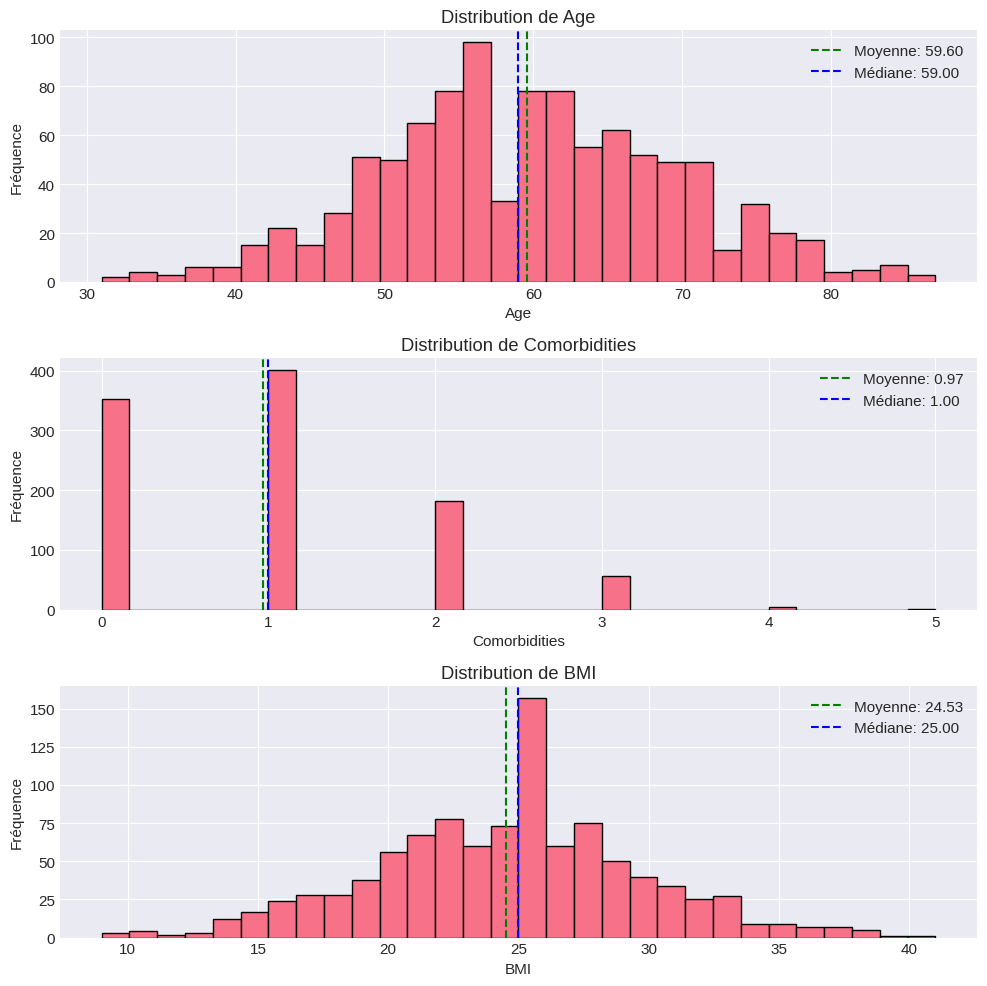

In [ ]:
# Visualisation des variables quantitatives
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes = axes.ravel()

for i, var in enumerate(quantitative_vars):
    axes[i].hist(df[var], bins=30, edgecolor='black')
    axes[i].set_title(f'Distribution de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Fréquence')
    axes[i].axvline(df[var].mean(), color='green', linestyle='--', label=f'Moyenne: {df[var].mean():.2f}')
    axes[i].axvline(df[var].median(), color='blue', linestyle='--', label=f'Médiane: {df[var].median():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

Les graphiques de distribution montrent que l’âge des patients est majoritairement centré autour de 60 ans, que le IMC est proche de 25 pour la plupart des individus, et que le nombre de comorbidités est généralement faible.

## 6. Analyse de Survie avec Kaplan-Meier

### 6.1 Estimation de la probabilité de survie globale

In [ ]:
# Initialisation du modèle Kaplan-Meier
kmf = KaplanMeierFitter()

# Ajustement du modèle sur les données
kmf.fit(durations=df['Time_to_Event'],
        event_observed=df['Event_Observed'],
        label='Survie globale')

print(f"Médiane de survie: {kmf.median_survival_time_:.2f} mois")
print(f"\nProbabilité de survie à différents moments:")
for t in [12, 24, 36, 60, 100]:
    prob = kmf.predict(t)
    print(f"  - À {t} mois: {prob:.4f} ({prob*100:.2f}%)")

Médiane de survie: 36.38 mois

Probabilité de survie à différents moments:
  - À 12 mois: 0.7872 (78.72%)
  - À 24 mois: 0.6093 (60.93%)
  - À 36 mois: 0.5046 (50.46%)
  - À 60 mois: 0.3333 (33.33%)
  - À 100 mois: 0.1992 (19.92%)


L’estimation de Kaplan–Meier montre que la médiane de survie est d’environ 36 mois. La probabilité de survie diminue petit à petit avec le temps, passant de 78,7 % à 12 mois à 19,9 % à 100 mois. Ces résultats montrent une augmentation du risque de décès au cours du suivi.

### 6.2 Tableau des proportions de survivants

In [ ]:
# Affichage du tableau des proportions de survivants
survival_table = kmf.survival_function_
print(survival_table.head(1000))
print('\n')

# Résumé avec événement
print("Résumé des événements:")
print(kmf.event_table.head(1000))

            Survie globale
timeline                  
0.000000          1.000000
0.051313          0.999000
0.068754          0.998000
0.090925          0.998000
0.146223          0.998000
...                    ...
329.845339        0.024569
346.453917        0.019655
350.643734        0.014742
412.236358        0.009828
434.249031        0.004914

[1000 rows x 1 columns]


Résumé des événements:
            removed  observed  censored  entrance  at_risk
event_at                                                  
0.000000          0         0         0      1000     1000
0.051313          1         1         0         0     1000
0.068754          1         1         0         0      999
0.090925          1         0         1         0      998
0.146223          1         0         1         0      997
...             ...       ...       ...       ...      ...
329.845339        1         0         1         0        6
346.453917        1         1         0         0        5
350.64373

Le tableau des proportions de survivants montre que la probabilité de survie diminue petit à petit au cours du temps, passant de 100 % au début du suivi à moins de 1 % en fin d’observation à 434 mois. Le tableau des événements montre la diminution du nombre de patients due aux décès et aux censures.

### 6.3 Courbe de survie globale avec intervalle de confiance

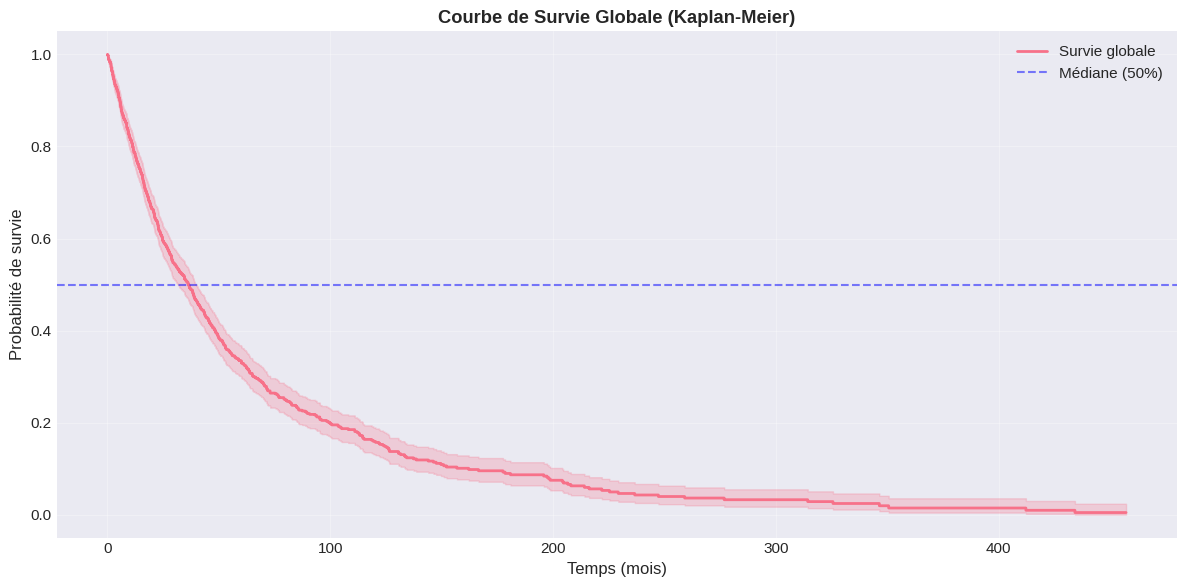

In [ ]:
# Tracé de la courbe de survie globale
plt.figure(figsize=(12, 6))
kmf.plot_survival_function(ci_show=True, linewidth=2)
plt.title('Courbe de Survie Globale (Kaplan-Meier)', fontweight='bold')
plt.xlabel('Temps (mois)', fontsize=12)
plt.ylabel('Probabilité de survie', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='blue', linestyle='--', alpha=0.5, label='Médiane (50%)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


La courbe de Kaplan–Meier montre l’évolution de la probabilité de survie globale des patients au cours du temps.

Au début du suivi, la probabilité de survie est égale à 1 (100 % des patients sont vivants). Puis, la survie diminue rapidement au cours des trois premières années, ce qui montre qu'il y a un risque élevé de décès au début. Ensuite, la courbe atteint la médiane de survie à 50 % autour de 36 mois et continue de dimunuer. Finalement, après 100 mois, la probabilité de survie devient faible, inférieure à 20 %.

La zone rose claire représente l'intervalle de confinace à 95% et donc l'insertitude de l'estimation.

### 6.4 Comparaison de la survie en fonction du sexe

Médiane de survie pour Female: 36.58 mois
Médiane de survie pour Male: 36.24 mois


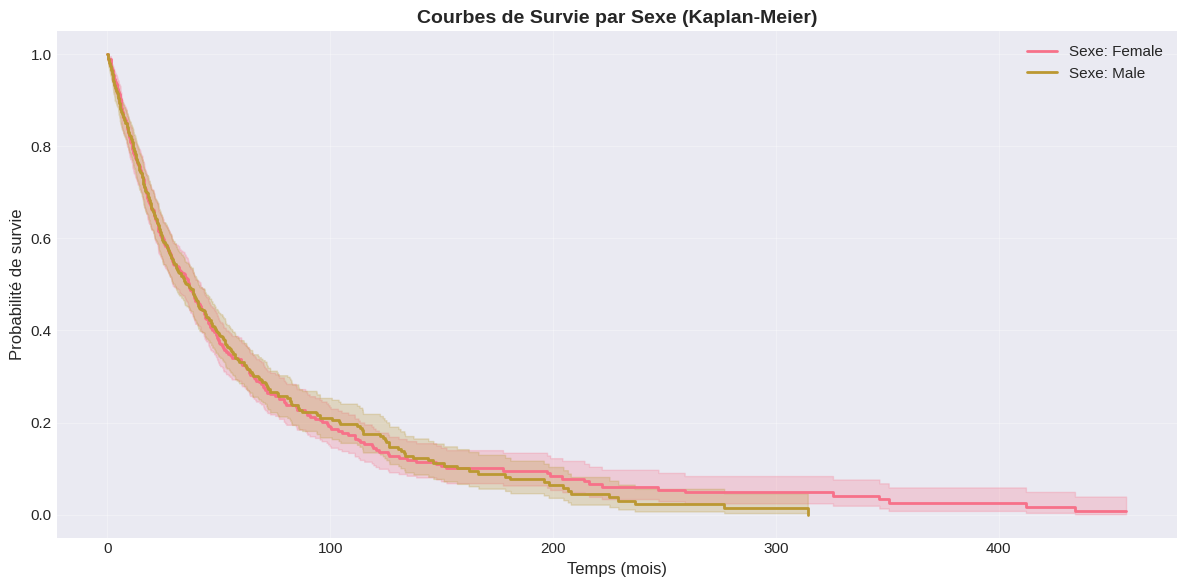

Résultats du test:
Statistique de test (χ²): 0.0475
p-value: 0.8275


In [ ]:
# Kaplan-Meier par sexe
plt.figure(figsize=(12, 6))

# Stocker les données pour le test
male_time = df[df['Sex']=='Male']['Time_to_Event']
male_event = df[df['Sex']=='Male']['Event_Observed']
female_time = df[df['Sex']=='Female']['Time_to_Event']
female_event = df[df['Sex']=='Female']['Event_Observed']

for sex in df['Sex'].unique():
    mask = df['Sex'] == sex
    kmf_sex = KaplanMeierFitter()
    kmf_sex.fit(durations=df[mask]['Time_to_Event'],
                event_observed=df[mask]['Event_Observed'],
                label=f'Sexe: {sex}')
    kmf_sex.plot_survival_function(ci_show=True, linewidth=2)

    print(f"Médiane de survie pour {sex}: {kmf_sex.median_survival_time_:.2f} mois")

plt.title('Courbes de Survie par Sexe (Kaplan-Meier)', fontsize=14, fontweight='bold')
plt.xlabel('Temps (mois)', fontsize=12)
plt.ylabel('Probabilité de survie', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

results = logrank_test(male_time, female_time, male_event, female_event)

print(f"Résultats du test:")
print(f"Statistique de test (χ²): {results.test_statistic:.4f}")
print(f"p-value: {results.p_value:.4f}")




Visuellement, on remarque que les deux courbes (Homme et Femme) du graphiques sont très proches et se superposent sur une grande partie du suivi des patients. Les intervalles de confiance se superposent aussi sur une grande partie, ce qui montre qu'il y a une absence de différence entre les deux groupes.

De plus, les médianes de survie sont similaires pour les hommes et les femmes (environ 36 mois), ce qui montre que 50 % des patients des deux groupes atteignent l’événement (décès ou censure) à des temps comparables.

Pour confirmer cette observation, on utilise le test du log-rank.

Hypothèses du test :
- H0 : les courbes de survie des hommes et des femmes sont identiques
- H1 : les courbes de survie sont différentes

Résultats du test :
- Statistique de test (χ²): 0.0475
- p-value: 0.8275

La p-value est supérieur au risque alphe (seuil de significativité) de 5%, on ne peut donc pas rejetter l'hypothèse nulle H0.

Conclusion :

Il n’existe pas de différence statistiquement significative entre la survie des hommes et des femmes. Le sexe ne semble donc pas avoir d’impact significatif sur la survie des patients.

Aussi, on peut voir que la courbe des femmes s’arrête plus loin (+ de 450 mois) dans le temps que celle des hommes (environ 315 mois). Cela s’explique par le fait que soit certaines femmes ont été suivies plus longtemps dans l'étude soit qu'elles sont restées en vie plus longtemps. Cependant, cette différence concerne très peu d’individus (7 femmes) et n’influence pas la conclusion globale du test statistique car celui ci compare les courbes sur toute leur durée commune.

## 7. Estimation de la fonction de risque (Nelson-Aalen)

### 7.1 Estimation du risque cumulé

In [ ]:
# Initialisation du modèle Nelson-Aalen
naf = NelsonAalenFitter()

# Ajustement du modèle
naf.fit(durations=df['Time_to_Event'],
        event_observed=df['Event_Observed'],
        label='Risque cumulé')

print("Modèle Nelson-Aalen ajusté")
print("\nRisque cumulé à différents moments:")
for t in [12, 24, 36, 60, 100]:
    risk = naf.predict(t)
    print(f"  - À {t} mois: {risk:.4f}")

Modèle Nelson-Aalen ajusté

Risque cumulé à différents moments:
  - À 12 mois: 0.2391
  - À 24 mois: 0.4951
  - À 36 mois: 0.6833
  - À 60 mois: 1.0975
  - À 100 mois: 1.6106


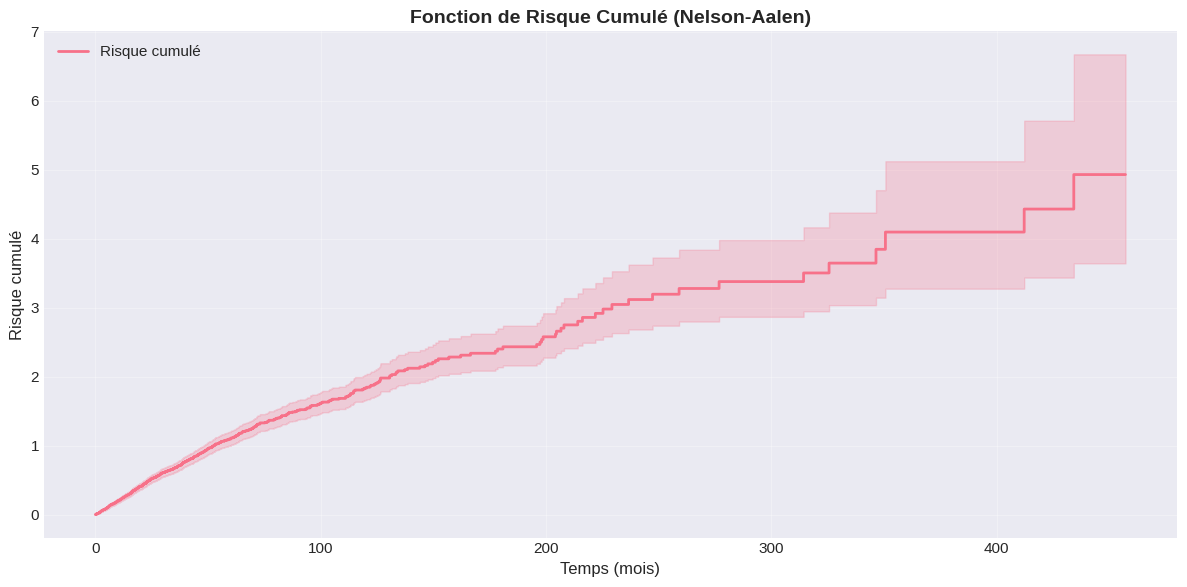

In [ ]:
# Tracé de la courbe de risque cumulé
plt.figure(figsize=(12, 6))
naf.plot_cumulative_hazard(ci_show=True, linewidth=2)
plt.title('Fonction de Risque Cumulé (Nelson-Aalen)', fontsize=14, fontweight='bold')
plt.xlabel('Temps (mois)', fontsize=12)
plt.ylabel('Risque cumulé', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La fonction de risque cumulée estimée par la méthode de Nelson–Aalen montre une augmentation progressive du risque de décès au cours du temps. Le risque est plus élevé durant les premières années, puis continue d’augmenter de façon moins rapide. L’intervalle de confiance grandit avec le temps, ce qui montre que l'incertitude est croissante et qu'elle est liée avec la diminution du nombre de patients à risque.

### 7.2 Explication de l'évolution du risque en fonction du temps

Analyse de la courbe :

La fonction de risque cumulée H(t) (Nelson–Aalen) augmente avec le temps, car elle représente l’accumulation du risque de décès au cours du suivi. Dans nos résultats :
- H(0) = 0 (début de l'étude)
- H(60) ≈ 1.10
- H(100) ≈ 1.61

Évolution du risque :

La courbe augmente de manière plutôt régulière, ce qui montre que le risque s’accumule tout au long du suivi. Les "marches" correspondent aux instants il y a des décès observés. À long terme, l’intervalle de confiance s'agrandit car il reste moins de patients avec un risque, donc l’estimation devient moins précise.

Lien avec la survie :

Il existe une relation approximative entre la survie et le risque cumulé : S(t) ≈ exp(−H(t))

On retrouve un lien avec Kaplan–Meier :

- H(12) ≈ 0.24 -> S(12) ≈ exp(−0.24) ≈ 0.79
- H(60) ≈ 1.10 -> S(60) ≈ exp(−1.10) ≈ 0.33
- H(100) ≈ 1.61 -> S(100) ≈ exp(−1.61) ≈ 0.20

Conclusion :

Le risque cumulé augmente progressivement avec le temps, sans phase de plateau. Ce qui montre qu'il y a une accumulation continue du risque de décès, donc l'hypothèse de risques proportionnels semble valide.

### 7.3 Estimation de la survie pour un temps donné

Utilisez la fonction `estimer_survie(temps_mois)` pour obtenir :
- Probabilité de survie (Kaplan-Meier)
- Risque cumulé (Nelson-Aalen)
- Visualisation graphique

**Exemple :** `estimer_survie(36)` donne la survie à 36 mois.

### 7.3.1 Estimation de la survie pour un temps donné (fonction interactive)

Exemples d'estimation de survie:

Estimation de survie à 12 mois:
Probabilité de survie (Kaplan-Meier): 0.7872 (78.72%)
Risque cumulé (Nelson-Aalen): 0.2391
Probabilité de décès: 0.2128 (21.28%)


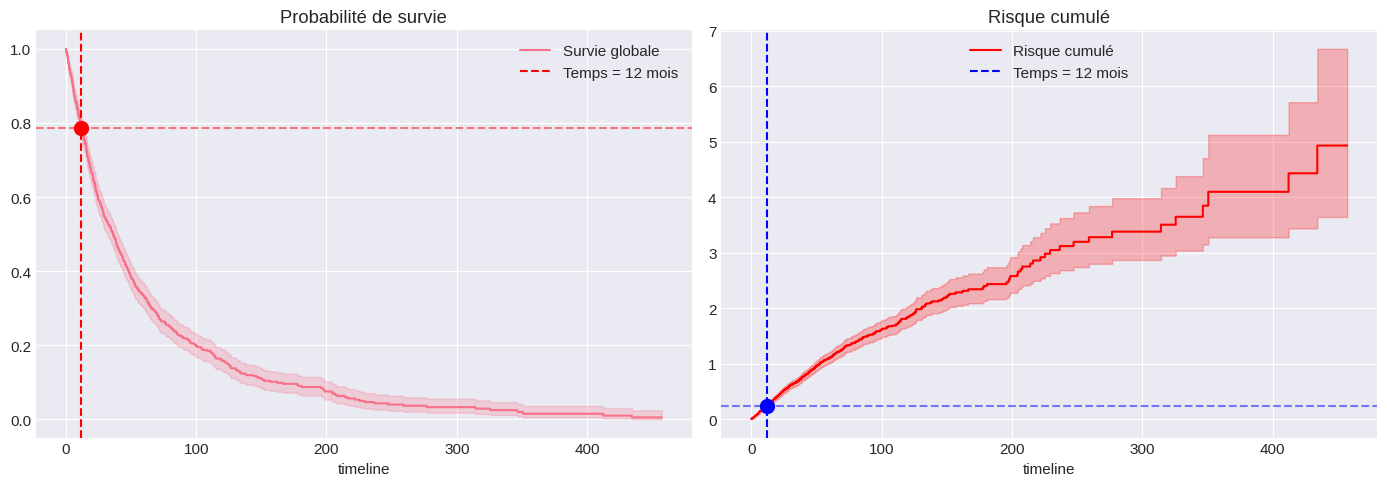


Estimation de survie à 24 mois:
Probabilité de survie (Kaplan-Meier): 0.6093 (60.93%)
Risque cumulé (Nelson-Aalen): 0.4951
Probabilité de décès: 0.3907 (39.07%)


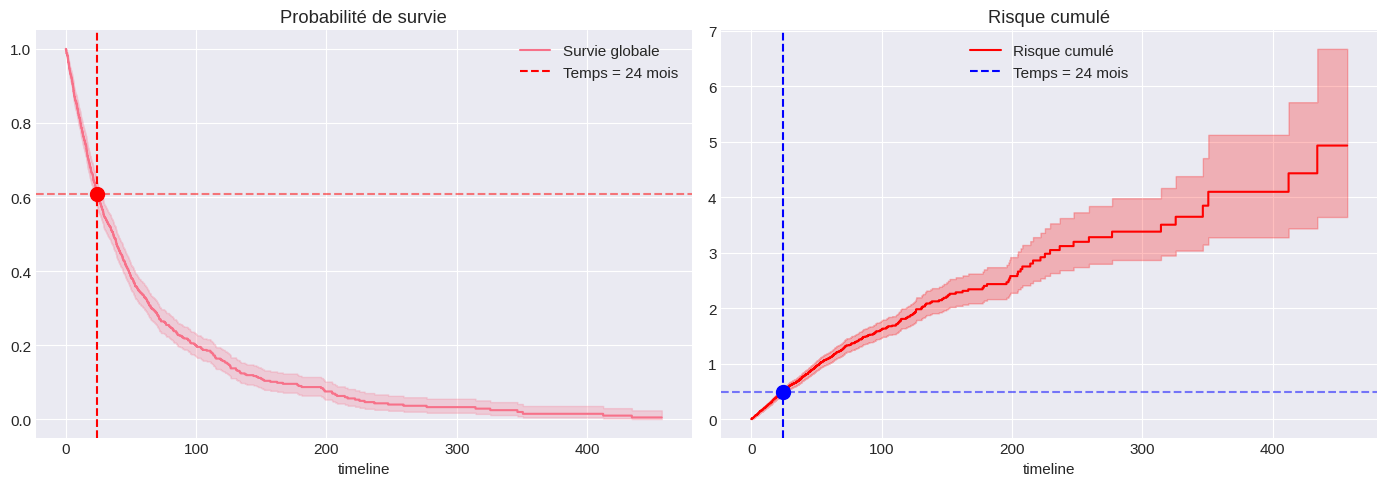


Estimation de survie à 50 mois:
Probabilité de survie (Kaplan-Meier): 0.3834 (38.34%)
Risque cumulé (Nelson-Aalen): 0.9576
Probabilité de décès: 0.6166 (61.66%)


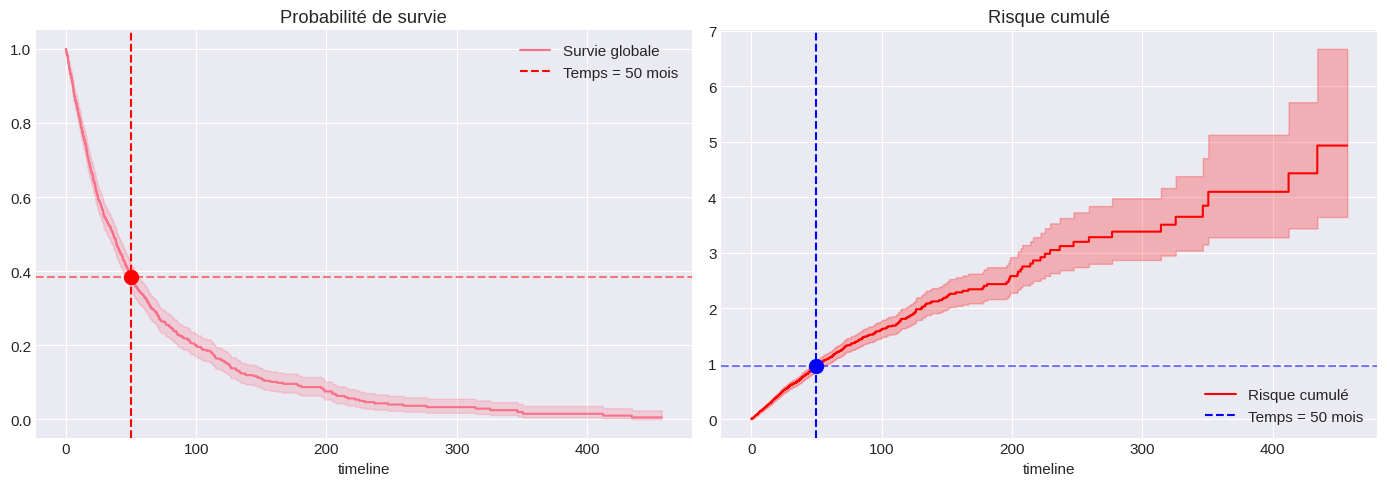


Estimation de survie à 100 mois:
Probabilité de survie (Kaplan-Meier): 0.1992 (19.92%)
Risque cumulé (Nelson-Aalen): 1.6106
Probabilité de décès: 0.8008 (80.08%)


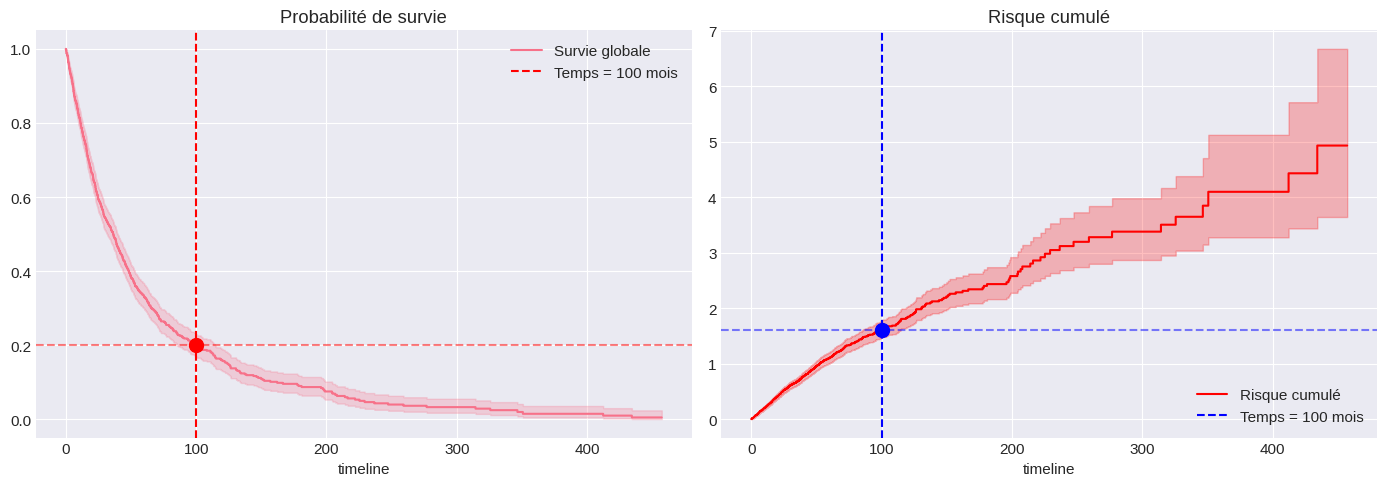

In [ ]:
def estimer_survie(temps_mois):
    """
    Estime la probabilité de survie à un temps donné

    Args:
        temps_mois: Temps en mois pour lequel on veut estimer la survie
    """
    # Utiliser le modèle Kaplan-Meier déjà ajusté
    prob_survie = kmf.predict(temps_mois)

    # Utiliser le modèle Nelson-Aalen pour le risque
    risque_cumule = naf.predict(temps_mois)

    print(f"\nEstimation de survie à {temps_mois} mois:")
    print(f"Probabilité de survie (Kaplan-Meier): {prob_survie:.4f} ({prob_survie*100:.2f}%)")
    print(f"Risque cumulé (Nelson-Aalen): {risque_cumule:.4f}")
    print(f"Probabilité de décès: {1-prob_survie:.4f} ({(1-prob_survie)*100:.2f}%)")

    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Courbe de survie
    kmf.plot_survival_function(ax=axes[0], ci_show=True)
    axes[0].axvline(x=temps_mois, color='red', linestyle='--', label=f'Temps = {temps_mois} mois')
    axes[0].axhline(y=prob_survie, color='red', linestyle='--', alpha=0.5)
    axes[0].scatter([temps_mois], [prob_survie], color='red', s=100, zorder=5)
    axes[0].set_title('Probabilité de survie')
    axes[0].legend()

    # Courbe de risque cumulé
    naf.plot_cumulative_hazard(ax=axes[1], ci_show=True, color='red')
    axes[1].axvline(x=temps_mois, color='blue', linestyle='--', label=f'Temps = {temps_mois} mois')
    axes[1].axhline(y=risque_cumule, color='blue', linestyle='--', alpha=0.5)
    axes[1].scatter([temps_mois], [risque_cumule], color='blue', s=100, zorder=5)
    axes[1].set_title('Risque cumulé')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Exemple d'utilisation
print("Exemples d'estimation de survie:")
for temps in [12, 24, 50, 100]:
    estimer_survie(temps)

### 7.4 Réponses aux questions théoriques

#### a) Que représente la fonction de risque cumulée estimée par la méthode de Nelson-Aalen ?

La fonction de risque cumulée H(t) représente le risque total accumulé de décès depuis le début de l'étude jusqu'au temps t.

Mathématiquement : H(t)=∫0t h(u)du

Elle mesure le nombre moyen d’événements attendus pour un individu s’il était suivi jusqu’au temps t.

#### b) Comment évolue le risque cumulatif avec le temps ? Que peut-on en déduire sur la maladie étudiée ?

In [ ]:
# Analyse de l'évolution du risque
cumulative_hazard = naf.cumulative_hazard_
time_points = cumulative_hazard.index
hazard_values = cumulative_hazard.values.flatten()

# Calcul du taux de croissance du risque
if len(time_points) > 1:
    mid_point = len(time_points) // 2
    early_rate = hazard_values[mid_point] / time_points[mid_point]
    late_rate = (hazard_values[-1] - hazard_values[mid_point]) / (time_points[-1] - time_points[mid_point])

    print(f"Taux moyen de risque (période précoce): {early_rate:.6f}")
    print(f"Taux moyen de risque (période tardive): {late_rate:.6f}")


Taux moyen de risque (période précoce): 0.020756
Taux moyen de risque (période tardive): 0.010233


La fonction de risque cumulée augmente progressivement avec le temps, mais son taux de croissance diminue. Cela suggère que les patients qui survivent plus longtemps ont un risque réduit (effet de sélection des plus résistants).

## 8. Régression de survie avec le Modèle de Cox

### 8.1 Préparation des données pour le modèle de Cox

In [ ]:
# Préparation des données
df_cox = df.copy()

# Encodage des variables catégorielles
# Sex: Male=1, Female=0
df_cox['Sex_Female'] = (df_cox['Sex'] == 'Female').astype(int)

# Treatment: Experimental=1, Standard=0
df_cox['Treatment_Experimental'] = (df_cox['Treatment'] == 'Experimental').astype(int)

# Physical_Activity: Low=0, Moderate=1, High=2 (ordinal)
# activity_map = {'Low': 0, 'Moderate': 1, 'High': 2}
# df_cox['Physical_Activity_Ordinal'] = df_cox['Physical_Activity'].map(activity_map)

# Utilisation des variables dummy pour Physical_Activity
df_cox = pd.get_dummies(df_cox, columns=['Physical_Activity'], prefix='Activity', drop_first=False)

print("\nVariables utilisées dans le modèle:")
cox_vars = ['Age', 'Sex_Female', 'Smoker', 'Treatment_Experimental',
            'Activity_High', 'Activity_Moderate']
print(cox_vars)


Variables utilisées dans le modèle:
['Age', 'Sex_Female', 'Smoker', 'Treatment_Experimental', 'Activity_High', 'Activity_Moderate']


On considère le niveau d’activité physique Low comme la catégorie de référence.

### 8.2 Ajustement du Modèle de Cox

In [ ]:
# Sélection des variables pour le modèle
cox_data = df_cox[['Time_to_Event', 'Event_Observed', 'Age', 'Sex_Female', 'Smoker',
                    'Treatment_Experimental', 'Activity_High', 'Activity_Moderate']].copy()

# Initialisation et ajustement du modèle de Cox
cph = CoxPHFitter()
cph.fit(cox_data, duration_col='Time_to_Event', event_col='Event_Observed')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1000 total observations, 289 right-censored observations>
             duration col = 'Time_to_Event'
                event col = 'Event_Observed'
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 711
   partial log-likelihood = -4126.67
         time fit was run = 2026-01-13 08:51:43 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
Age                     0.03      1.03      0.00            0.03            0.04                1.03                1.04
Sex_Female              0.03      1.03      0.08           -0.12            0.18                0.89                1.20
Smoker                  0.39      1.48      0.08            0.24            0.55                1.27                1.73
Treatment_Experimental -0.34      0.71      0.09           -0.51           -0.17                0.60                0.84
Activity_High          -0.73      0.48      0.11           -0.94           -0.52                0.39                0.59
Activity_Moderate      -0.35      0.70      0.09           -0.53           -0.18                0.59                0.84

                        cmp to     z      p  -log2(p)
covariate                                            
Age                       0.00  8.60 <0.005     56.83
Sex_Female                0.00  0.44   0.66      0.60
Smoker                    0.00  4.96 <0.005     20.44
Treatment_Experimental    0.00 -3.99 <0.005     13.90
Activity_High             0.00 -6.83 <0.005     36.77
Activity_Moderate         0.00 -4.00 <0.005     13.97
---
Concordance = 0.64
Partial AIC = 8265.33
log-likelihood ratio test = 148.19 on 6 df
-log2(p) of ll-ratio test = 95.44

### 8.3 Interprétation des coefficients (Hazard Ratios)

In [ ]:
# Extraction des Hazard Ratios
print("Un HR > 1 risque AUGMENTÉ")
print("Un HR < 1 risque DIMINUÉ")
print("Un HR = 1 aucun effet\n")

hazard_ratios = np.exp(cph.params_)
ci = np.exp(cph.confidence_intervals_)

interpretation_df = pd.DataFrame({
    'Variable': hazard_ratios.index,
    'Hazard Ratio': hazard_ratios.values,
    'HR Lower 95%': ci.iloc[:, 0].values,
    'HR Upper 95%': ci.iloc[:, 1].values,
    'p-value': cph.summary['p'].values
})

print(interpretation_df.to_string(index=False))


Un HR > 1 risque AUGMENTÉ
Un HR < 1 risque DIMINUÉ
Un HR = 1 aucun effet

              Variable  Hazard Ratio  HR Lower 95%  HR Upper 95%      p-value
                   Age      1.034204      1.026309      1.042160 7.831461e-18
            Sex_Female      1.034079      0.891197      1.199869 6.587052e-01
                Smoker      1.479180      1.267201      1.726618 7.024792e-07
Treatment_Experimental      0.710262      0.600439      0.840173 6.552567e-05
         Activity_High      0.480252      0.389097      0.592761 8.509578e-12
     Activity_Moderate      0.702723      0.591279      0.835170 6.216158e-05


L’âge augmente significativement le risque de décès (HR = 1.034, p < 0.005). Chaque année supplémentaire augmente le risque d’environ 3.4%.

Le tabagisme augmente significativement le risque de décès (HR = 1.479, p < 0.005), avec environ 48% de plus de risque de décès chez les fumeurs que chez les non-fumeurs.

Le traitement expérimental réduit significativement le risque de décès (HR = 0.710, p < 0.005) d’environ 29 % par rapport au traitement standard.

Avoir une activité physique élevée permet une forte réduction du risque (HR = 0.480, p < 0.005), avec une diminution d’environ 52 % du risque de décès.

Avoir une activité physique modérée permet aussi de réduire le risque (HR = 0.703, p < 0.005), avec une réduction du risque d’environ 30 %.

Le sexe n’a pas d’effet significatif sur la survie (p = 0.659).

Conclusion

L’âge et le tabagisme augmentent significativement le risque de décès, alors que le traitement expérimental et l’activité physique réduit ce risque. Le sexe ne semble pas influencer la survie.

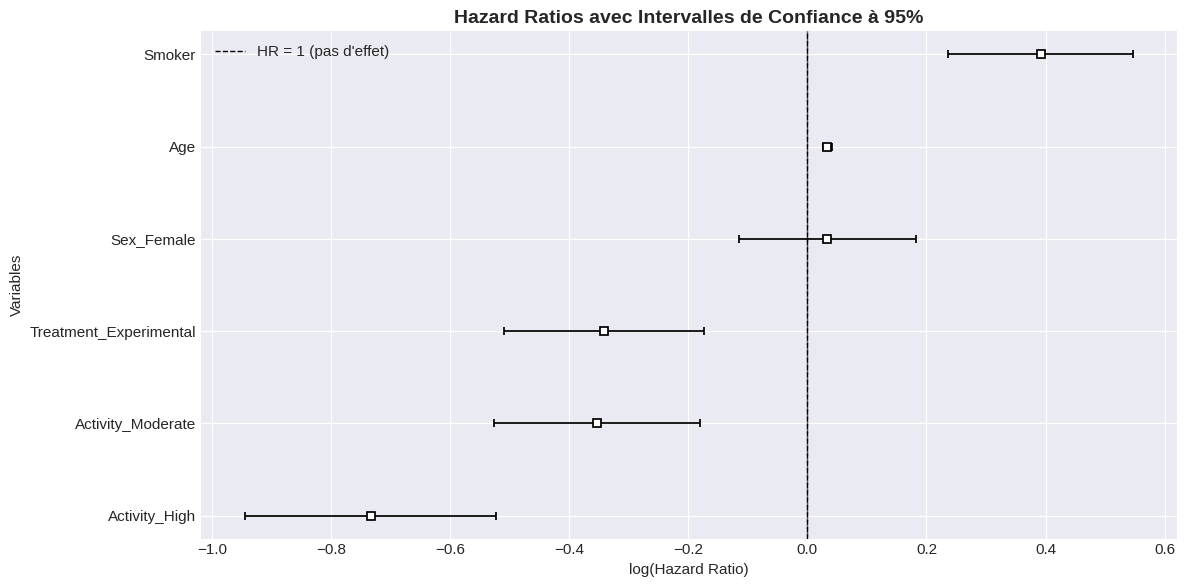

In [ ]:
# Visualisation des Hazard Ratios
plt.figure(figsize=(12, 6))
cph.plot()
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='HR = 1 (pas d\'effet)')
plt.title('Hazard Ratios avec Intervalles de Confiance à 95%', fontsize=14, fontweight='bold')
plt.xlabel('log(Hazard Ratio)')
plt.ylabel('Variables')
plt.legend()
plt.tight_layout()
plt.show()


Les barres qui ne croisent pas la ligne verticale (HR=1) sont statistiquement significatives.

(La ligne verticale correspond à log(HR) = 0, soit HR = 1)

La visualisation graphique confirme nos résultats.

On remarque que le tabagisme et l’âge ont des coefficients positifs donc qu'ils sont associés à une augmentation du risque de décès. Le traitement expérimental et l’activité physique modérée et élevée ont des coefficients négatifs donc qu'ils ont un effet protecteur.

Le sexe n’a pas d’effet significatif, car son intervalle de confiance inclut la valeur 0.


### 8.4 Vérification des hypothèses du modèle de Cox

Hypothèse principale : Proportionnalité des risques

Le modèle de Cox suppose que le ratio des risques entre deux groupes reste constant dans le temps.

H0 : Les risques sont proportionnels (hypothèse respectée)
Si p < 0.05 : l'hypothèse de proportionnalité n'est pas respectée


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


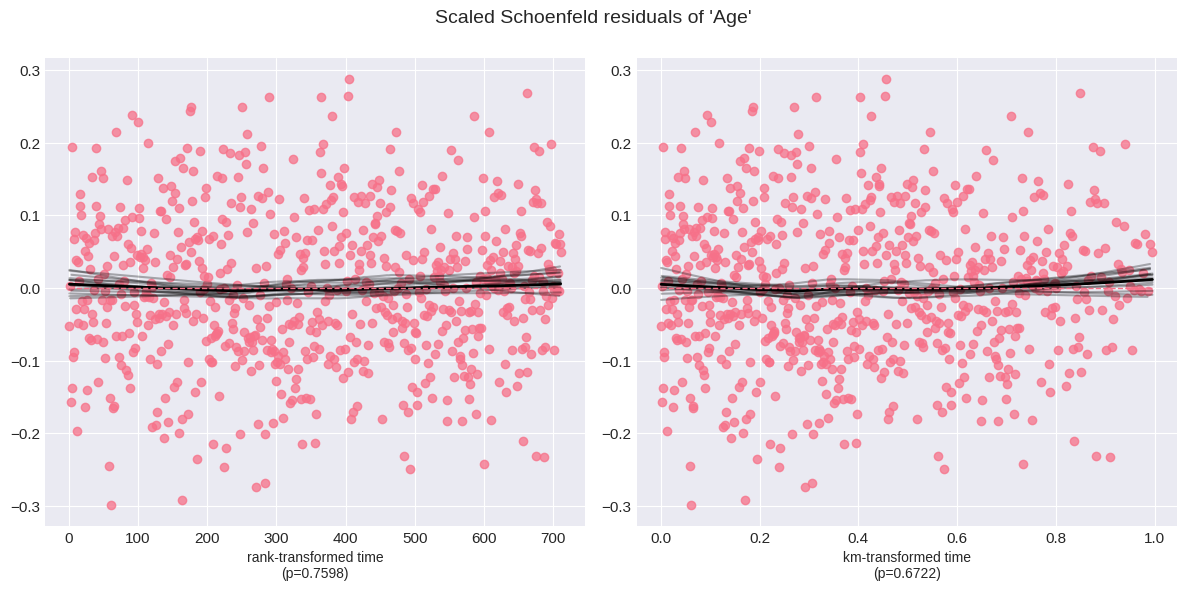

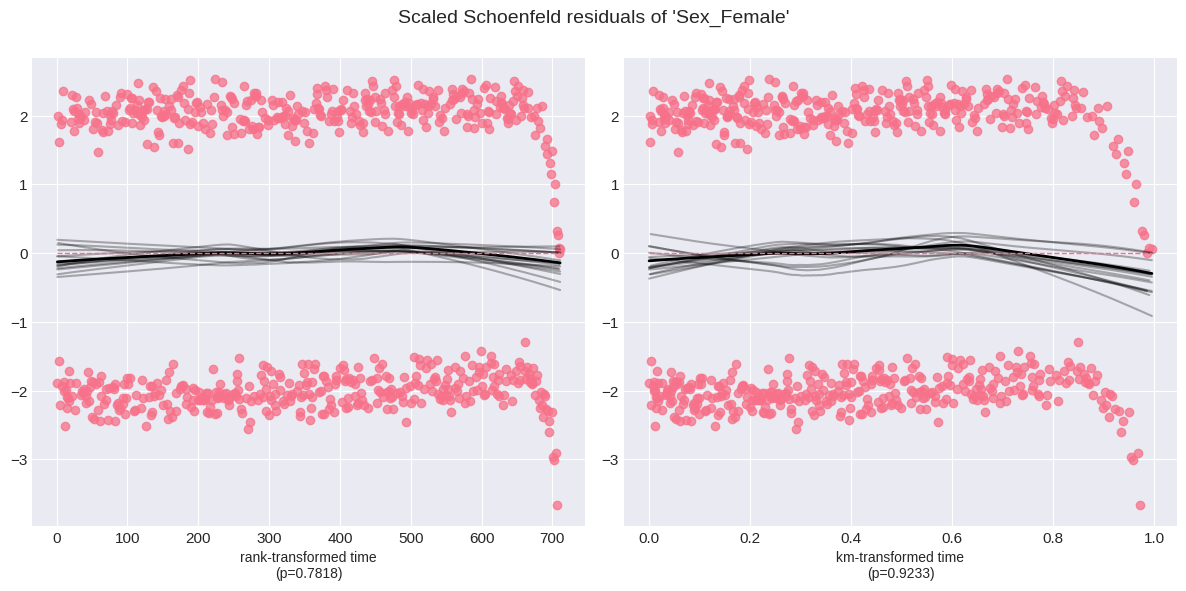

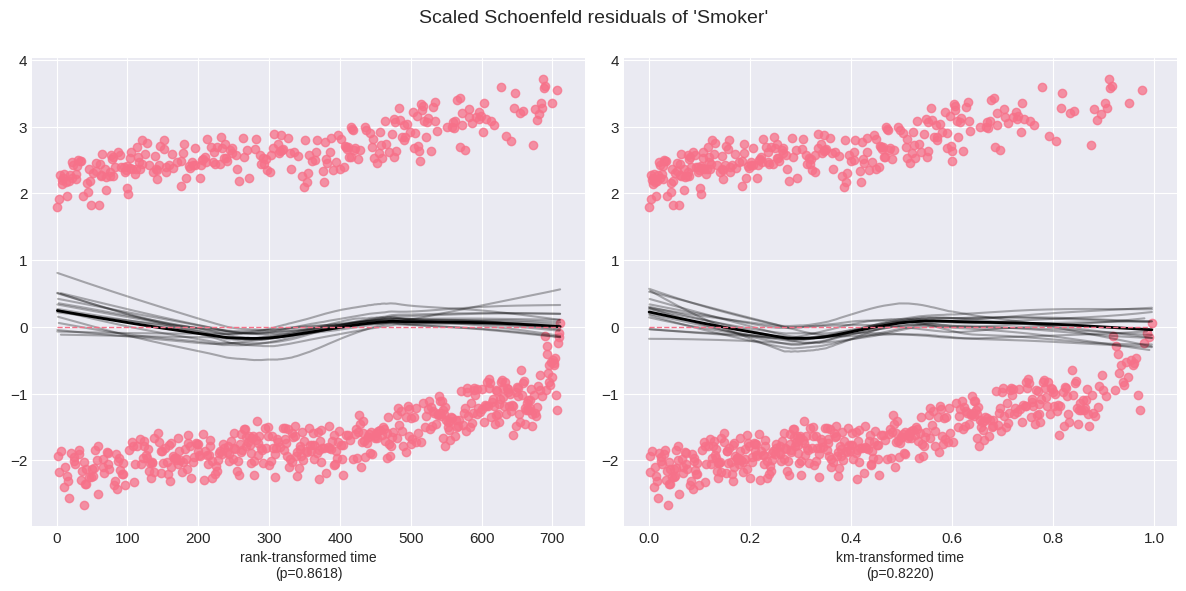

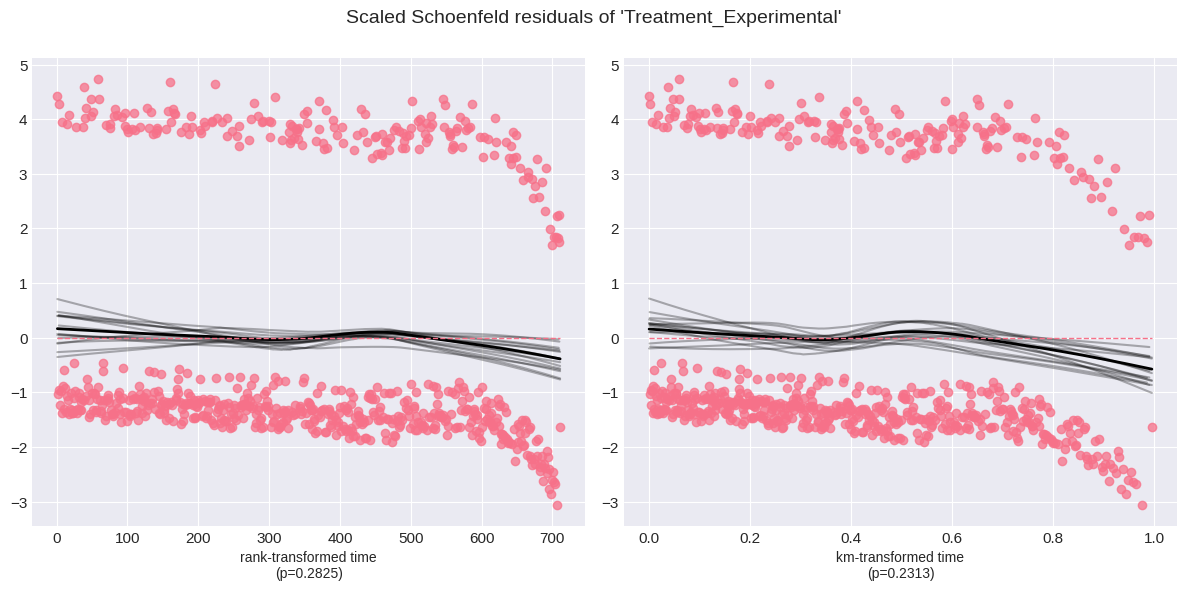

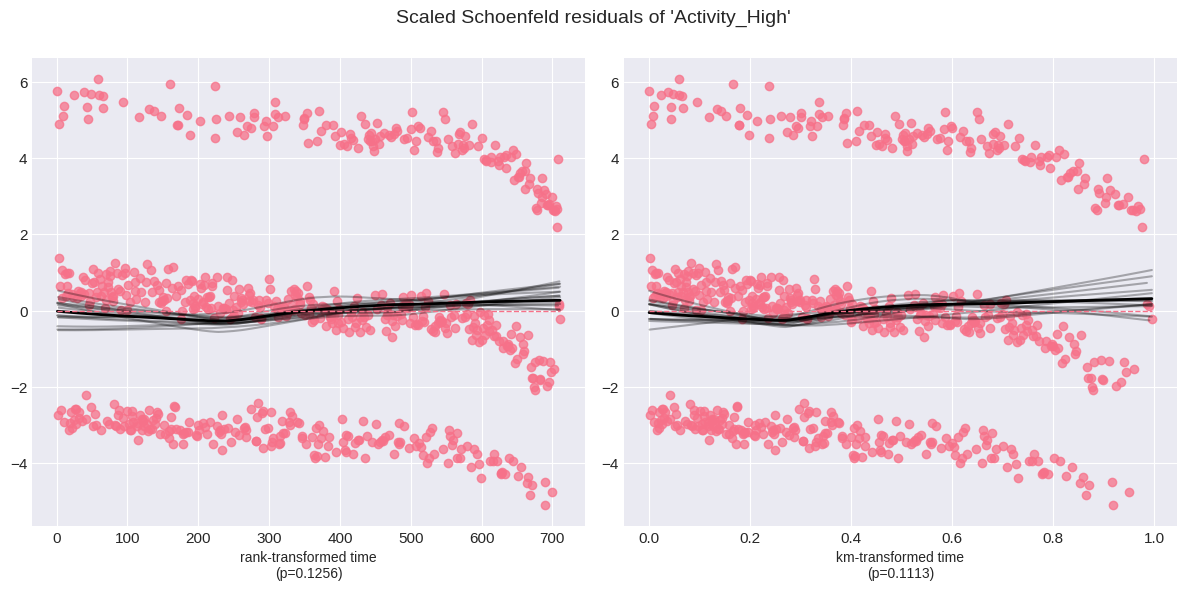

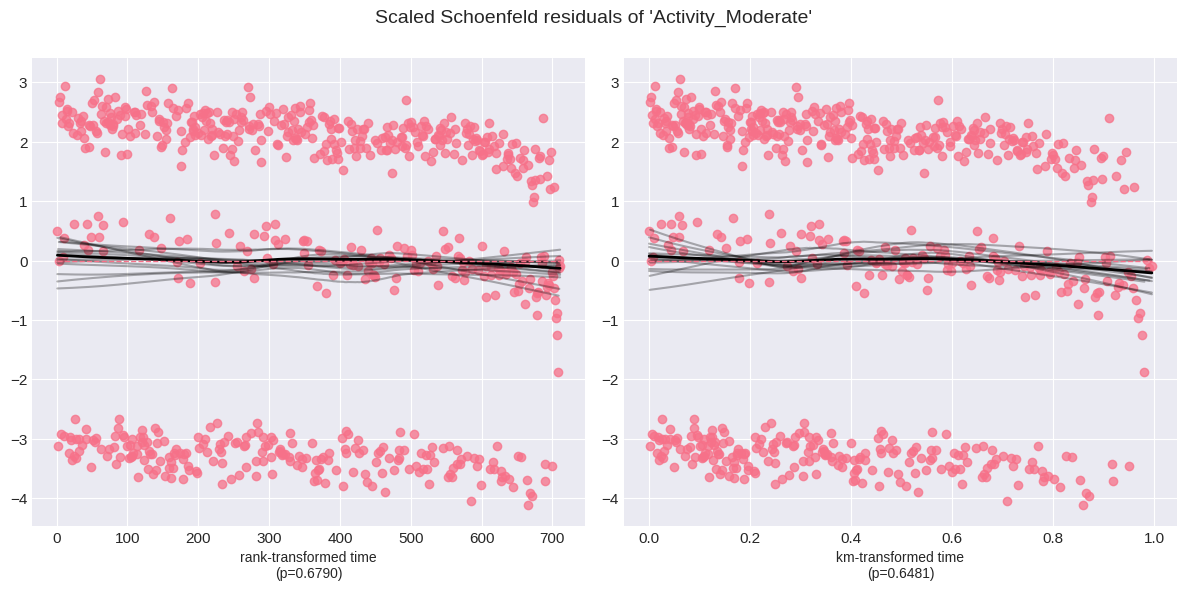

In [ ]:
# Test de proportionnalité des risques (Schoenfeld residuals)
from lifelines.statistics import proportional_hazard_test
print("H0 : Les risques sont proportionnels (hypothèse respectée)")
print("Si p < 0.05 : l'hypothèse de proportionnalité n'est pas respectée\n")

# Test pour chaque variable
results_ph = cph.check_assumptions(cox_data, p_value_threshold=0.05, show_plots=True)

p-value (rank) : test basé sur les rangs des temps d’événement

p-value (km) :approche basée sur l’estimation Kaplan–Meier

Synthèse du test de proportionnalité des risques

Résultats pour chaque variable :

| Variable | p-value (rank) | p-value (km) | Hypothèse respectée ? | Interprétation |
|----------|----------------|--------------|----------------------|----------------|
| Age | 0.7598 | 0.6722 | oui | Effet de l'âge constant dans le temps |
| Sex_Female | 0.7818 | 0.9233 | oui | Effet du sexe constant dans le temps |
| Smoker | 0.8618 | 0.8220 | oui | Effet du tabagisme constant dans le temps |
| Treatment_Experimental | 0.2825 | 0.2313 | oui | Effet du traitement constant dans le temps |
| Activity_High | 0.1250 | 0.1113 | oui | Effet de l'activité élevée constant dans le temps |
| Activity_Moderate | 0.6790 | 0.6481 | oui | Effet de l'activité modérée constant dans le temps |

Lecture des graphiques :
- Ligne plate proche de 0 + p > 0.05 = Hypothèse respectée
- Ligne avec pente + p < 0.05 = Hypothèse pas respectée

Conclusion :

Toutes les p-values sont supérieures au seuil de 0.05.
L’hypothèse de proportionnalité des risques est donc respectée pour toutes des variables.

Le modèle de Cox peut donc être utilisé de manière fiable :

- Les Hazard Ratios peuvent être interprétés correctement
- Les effets des covariables sont constants dans le temps
- Pas besoin de modèle stratifié ou de variables dépendantes du temps

### 8.5 Visualisation des courbes de survie ajustées

Courbes de survie ajustées pour différents profils de patients:

Profil 1 – Homme, 60 ans, fumeur, traitement standard, activité faible
  Médiane de survie: 18.31 mois

Profil 2 – Femme, 50 ans, non-fumeur, traitement expérimental, activité élevée
  Médiane de survie: 115.23 mois

Profil 3 – Homme, 40 ans, fumeur, traitement standard, activité modérée
  Médiane de survie: 49.94 mois



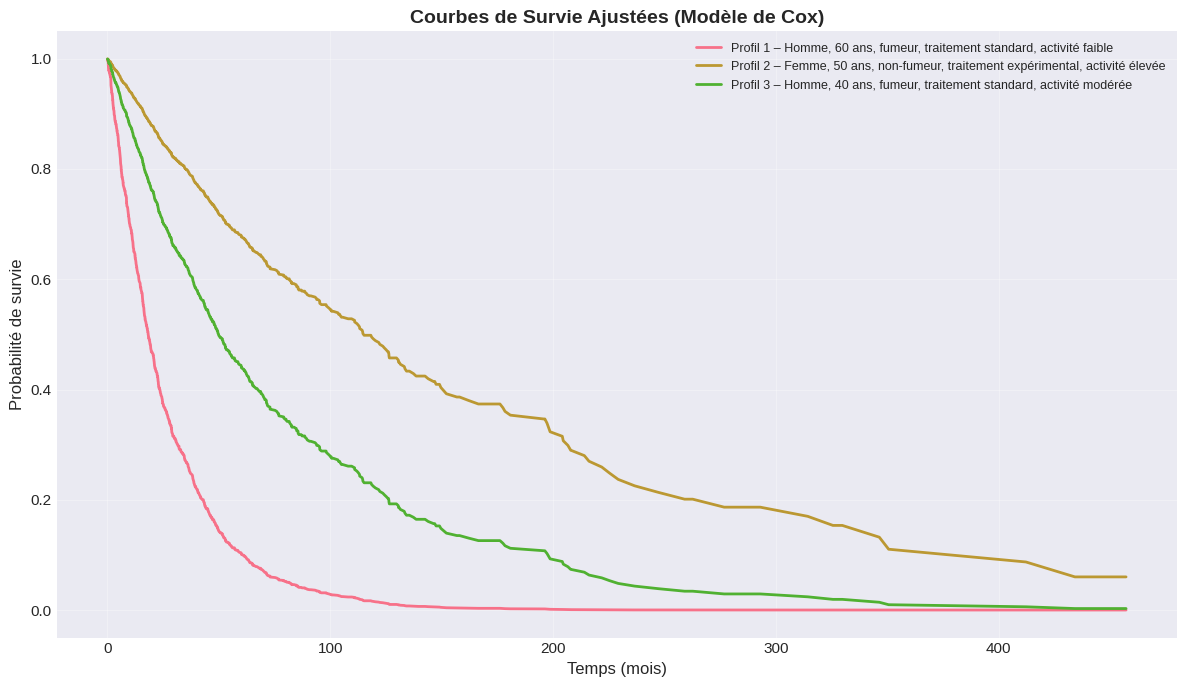

In [ ]:
# Courbes de survie pour différents profils de patients
# Profil 1: Homme, 60 ans, fumeur, traitement standard, activité faible
# Profil 2: Femme, 50 ans, non-fumeur, traitement expérimental, activité élevée
# Profil 3: Homme, 70 ans, fumeur, traitement standard, activité modérée

print("Courbes de survie ajustées pour différents profils de patients:\n")

profiles = pd.DataFrame({
    'Age': [60, 50, 40],
    'Sex_Female': [0, 1, 0],
    'Smoker': [1, 0, 1],
    'Treatment_Experimental': [0, 1, 0],
    'Activity_High': [0, 1, 0],
    'Activity_Moderate': [0, 0, 1]
})

profile_labels = [
    'Profil 1 – Homme, 60 ans, fumeur, traitement standard, activité faible',
    'Profil 2 – Femme, 50 ans, non-fumeur, traitement expérimental, activité élevée',
    'Profil 3 – Homme, 40 ans, fumeur, traitement standard, activité modérée'
]

fig, ax = plt.subplots(figsize=(12, 7))

for label, profile in zip(profile_labels, profiles.to_dict('records')):
    profile_df = pd.DataFrame([profile])

    surv_df = cph.predict_survival_function(profile_df)
    y = surv_df.iloc[:, 0]

    ax.plot(surv_df.index, y.values, linewidth=2, label=label)

    median_surv = cph.predict_median(profile_df)
    print(f"{label}")
    print(f"  Médiane de survie: {median_surv:.2f} mois\n")

ax.set_title('Courbes de Survie Ajustées (Modèle de Cox)', fontsize=14, fontweight='bold')
ax.set_xlabel('Temps (mois)', fontsize=12)
ax.set_ylabel('Probabilité de survie', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()



Profil 1 = profil à risque élevé

Profil 2 = profil protecteur

Profil 3 = profil intermédiaire

Le modèle de Cox a montré que l’âge et le tabagisme augmentent significativement le risque de décès, alors que le traitement expérimental et l'activité physique réduisent le risque.

Sur le graphique, la courbe du profil 1 chute rapidement, ce qui montre une probabilité de survie plus faible.
À l’inverse, le profil 2 montre la meilleure survie au cours du temps.
Le profil 3 est entre les deux, ce qui est cohérent avec ses caractéristiques intermédiaires.

Ces résultats sont cohérents avec les Hazard Ratios estimés par le modèle de Cox.

### 8.6 Comparaison par traitement (Standard vs Expérimental)

Traitement Standard:
  Médiane de survie: 32.42 mois
  Nombre de patients: 726
  Nombre d'événements: 517

Traitement Experimental:
  Médiane de survie: 43.59 mois
  Nombre de patients: 274
  Nombre d'événements: 194



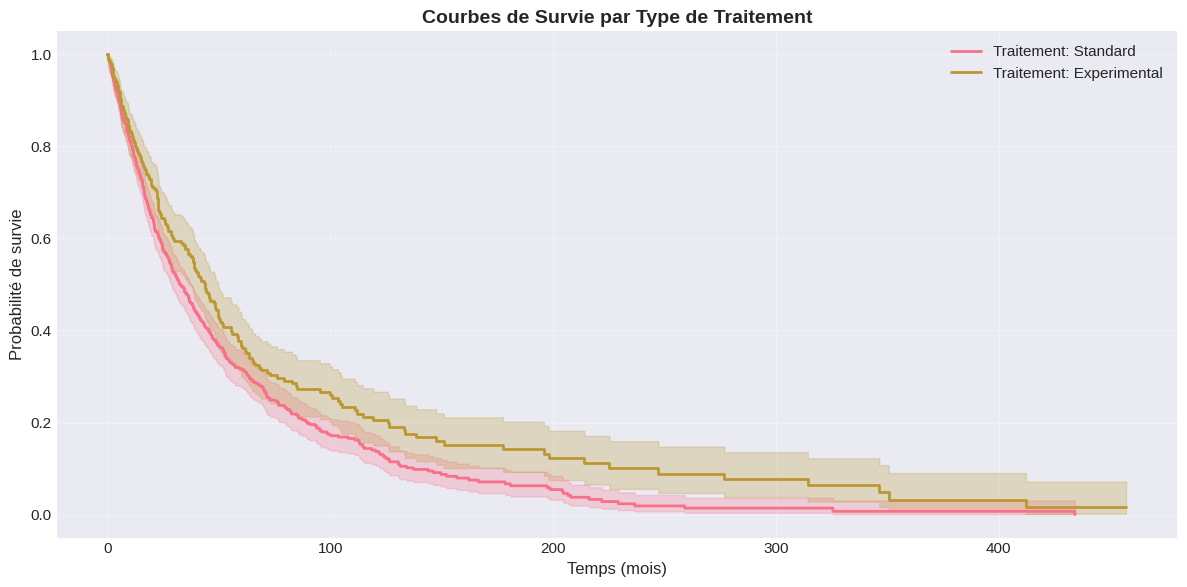

Test du Log-Rank (Standard vs Expérimental):
p-value: 0.0027
Différence significative entre les traitements (p < 0.05)


In [ ]:
# Courbes de survie Kaplan-Meier par type de traitement
plt.figure(figsize=(12, 6))

for treatment in df['Treatment'].unique():
    mask = df['Treatment'] == treatment
    kmf_treatment = KaplanMeierFitter()
    kmf_treatment.fit(durations=df[mask]['Time_to_Event'],
                      event_observed=df[mask]['Event_Observed'],
                      label=f'Traitement: {treatment}')
    kmf_treatment.plot_survival_function(ci_show=True, linewidth=2)

    print(f"Traitement {treatment}:")
    print(f"  Médiane de survie: {kmf_treatment.median_survival_time_:.2f} mois")
    print(f"  Nombre de patients: {mask.sum()}")
    print(f"  Nombre d'événements: {df[mask]['Event_Observed'].sum()}\n")

plt.title('Courbes de Survie par Type de Traitement', fontsize=14, fontweight='bold')
plt.xlabel('Temps (mois)', fontsize=12)
plt.ylabel('Probabilité de survie', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Test statistique
results_treatment = logrank_test(
    df[df['Treatment']=='Standard']['Time_to_Event'],
    df[df['Treatment']=='Experimental']['Time_to_Event'],
    df[df['Treatment']=='Standard']['Event_Observed'],
    df[df['Treatment']=='Experimental']['Event_Observed']
)

print(f"Test du Log-Rank (Standard vs Expérimental):")
print(f"p-value: {results_treatment.p_value:.4f}")
if results_treatment.p_value < 0.05:
    print("Différence significative entre les traitements (p < 0.05)")
else:
    print("Pas de différence significative entre les traitements (p ≥ 0.05)")

### 8.7 Analyse par activité physique

Activité physique Low:
  Médiane de survie: 24.80 mois
  Nombre de patients: 293

Activité physique Moderate:
  Médiane de survie: 34.58 mois
  Nombre de patients: 490

Activité physique High:
  Médiane de survie: 52.93 mois
  Nombre de patients: 217



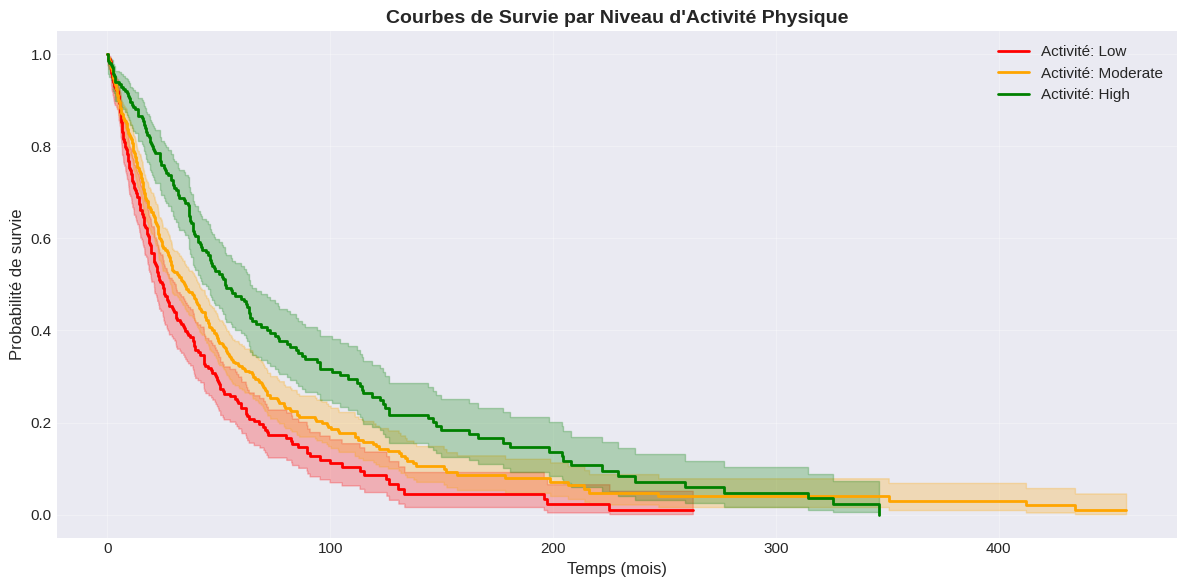


Test du Log-Rank multivarié (activité physique):
p-value: 0.0000
Différence significative entre les niveaux d'activité (p < 0.05)


In [ ]:
# Courbes de survie par niveau d'activité physique
plt.figure(figsize=(12, 6))

activity_order = ['Low', 'Moderate', 'High']
colors = ['red', 'orange', 'green']

for activity, color in zip(activity_order, colors):
    mask = df['Physical_Activity'] == activity
    kmf_activity = KaplanMeierFitter()
    kmf_activity.fit(durations=df[mask]['Time_to_Event'],
                     event_observed=df[mask]['Event_Observed'],
                     label=f'Activité: {activity}')
    kmf_activity.plot_survival_function(ci_show=True, linewidth=2, color=color)

    print(f"Activité physique {activity}:")
    print(f"  Médiane de survie: {kmf_activity.median_survival_time_:.2f} mois")
    print(f"  Nombre de patients: {mask.sum()}\n")

plt.title('Courbes de Survie par Niveau d\'Activité Physique', fontsize=14, fontweight='bold')
plt.xlabel('Temps (mois)', fontsize=12)
plt.ylabel('Probabilité de survie', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Test multivarié
results_activity = multivariate_logrank_test(
    df['Time_to_Event'],
    df['Physical_Activity'],
    df['Event_Observed']
)

print(f"\nTest du Log-Rank multivarié (activité physique):")
print(f"p-value: {results_activity.p_value:.4f}")
if results_activity.p_value < 0.05:
    print("Différence significative entre les niveaux d'activité (p < 0.05)")
else:
    print("Pas de différence significative entre les niveaux d'activité (p ≥ 0.05)")

## 9. Synthèse et Conclusions

### 9.1 Résumé des résultats principaux

In [ ]:
print("="*70)
print("SYNTHÈSE DE L'ANALYSE DE SURVIE")
print("="*70)

print("\n1. STATISTIQUES DESCRIPTIVES:")
print("-" * 70)
print(f"   • Nombre total de patients: {len(df)}")
print(f"   • Nombre d'événements (décès): {df['Event_Observed'].sum()}")
print(f"   • Taux d'événements: {df['Event_Observed'].mean()*100:.1f}%")
print(f"   • Temps médian de suivi: {df['Time_to_Event'].median():.2f} mois")
print(f"   • Âge moyen: {df['Age'].mean():.1f} ans (écart-type: {df['Age'].std():.1f})")

print("\n2. ANALYSE KAPLAN-MEIER:")
print("-" * 70)
print(f"   • Médiane de survie globale: {kmf.median_survival_time_:.2f} mois")
print(f"   • Probabilité de survie à 12 mois: {kmf.predict(12):.2%}")
print(f"   • Probabilité de survie à 24 mois: {kmf.predict(24):.2%}")
print(f"   • Probabilité de survie à 60 mois: {kmf.predict(60):.2%}")

print("\n3. MODÈLE DE COX - FACTEURS DE RISQUE SIGNIFICATIFS:")
print("-" * 70)
significant_vars = cph.summary[cph.summary['p'] < 0.05]
if len(significant_vars) > 0:
    for idx, row in significant_vars.iterrows():
        hr = np.exp(row['coef'])
        print(f"   • {idx}:")
        print(f"     - Hazard Ratio: {hr:.3f}")
        print(f"     - p-value: {row['p']:.4f}")
        if hr > 1:
            print(f"     - Effet: Augmente le risque de {(hr-1)*100:.1f}%")
        else:
            print(f"     - Effet: Réduit le risque de {(1-hr)*100:.1f}%")
else:
    print("   Aucun facteur significatif au seuil de 5%")

print("\n4. RECOMMANDATIONS METIERS:")
print("-" * 70)
print("   Basées sur les résultats du modèle de Cox:")

# Traitement
if 'Treatment_Experimental' in significant_vars.index:
    hr_treatment = np.exp(significant_vars.loc['Treatment_Experimental', 'coef'])
    if hr_treatment < 1:
        print(f"   • Le traitement expérimental est BÉNÉFIQUE (réduit le risque)")
    else:
        print(f"   • Le traitement standard est préférable")
else:
    print(f"   • Pas de différence significative entre les traitements")

# Activité physique
if 'Activity_High' in significant_vars.index:
    hr_activity = np.exp(significant_vars.loc['Activity_High', 'coef'])
    if hr_activity < 1:
        print(f"   • L'activité physique élevée est PROTECTRICE")
else:
    print(f"   • Impact de l'activité physique non significatif")

print("\n5. CONCLUSION GENERALE:")
print("-" * 70)
print("   Cette analyse de survie a permis d’identifier plusieurs facteurs influençant significativement la durée de survie des patients.")
print("   L’âge et le tabagisme augmentent de manière significative le risque de décès, les patients plus âgés et fumeurs présentent une")
print("   probabilité de survie plus faible.")

print("   À l’inverse, le traitement expérimental et un niveau d’activité physique modéré ou élevé amènent à une réduction du risque, ce")
print("   qui indique qu'ils ont un effet protecteur sur la survie.")

print("   Le sexe n’a pas montré d’impact statistiquement significatif sur la survie, ce qui signifie que les différences observées entre ")
print("   hommes et femmes peuvent être dues au hasard.")

print("   L’hypothèse de proportionnalité des risques a été vérifiée et respectée pour l’ensemble des variables, ce qui confirme la")
print("   validité du modèle de Cox utilisé.")

print("   Enfin, les courbes de survie ajustées confirment visuellement ces résultats : les profils à risque élevé (patients âgés, fumeurs,")
print("   peu actifs) présentent une chute rapide de la survie, tandis que les profils protecteurs (patients plus jeunes, non-fumeurs,")
print("   actifs et sous traitement expérimental) présentent une survie nettement meilleure.")

print("   Cette étude met ainsi en évidence l’importance des facteurs comportementaux et thérapeutiques dans l’amélioration de la survie")
print("   des patients.")


print("\n" + "="*70)
print("FIN DE L'ANALYSE")
print("="*70)

SYNTHÈSE DE L'ANALYSE DE SURVIE

1. STATISTIQUES DESCRIPTIVES:
----------------------------------------------------------------------
   • Nombre total de patients: 1000
   • Nombre d'événements (décès): 711
   • Taux d'événements: 71.1%
   • Temps médian de suivi: 23.82 mois
   • Âge moyen: 59.6 ans (écart-type: 9.9)

2. ANALYSE KAPLAN-MEIER:
----------------------------------------------------------------------
   • Médiane de survie globale: 36.38 mois
   • Probabilité de survie à 12 mois: 78.72%
   • Probabilité de survie à 24 mois: 60.93%
   • Probabilité de survie à 60 mois: 33.33%

3. MODÈLE DE COX - FACTEURS DE RISQUE SIGNIFICATIFS:
----------------------------------------------------------------------
   • Age:
     - Hazard Ratio: 1.034
     - p-value: 0.0000
     - Effet: Augmente le risque de 3.4%
   • Smoker:
     - Hazard Ratio: 1.479
     - p-value: 0.0000
     - Effet: Augmente le risque de 47.9%
   • Treatment_Experimental:
     - Hazard Ratio: 0.710
     - p-value: 0.

## 10. Analyses complémentaires

### 10.1 Analyse par tranches d'âge

Tranche d'âge <50:
  Médiane de survie: 59.08 mois
  Nombre de patients: 152

Tranche d'âge 50-60:
  Médiane de survie: 43.57 mois
  Nombre de patients: 402

Tranche d'âge >60:
  Médiane de survie: 26.20 mois
  Nombre de patients: 446



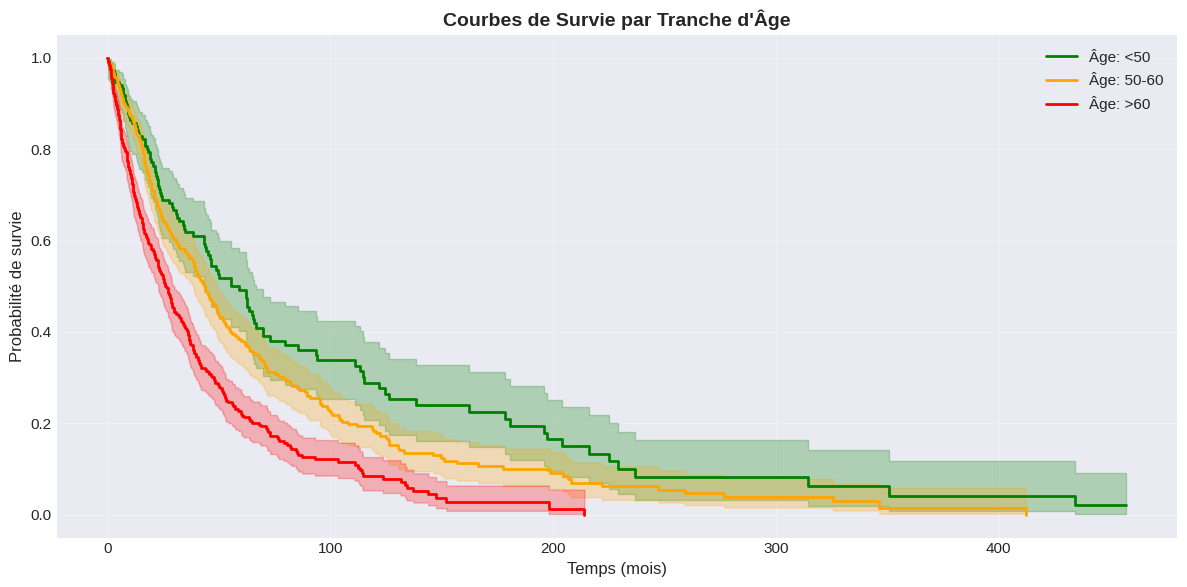


Test du Log-Rank multivarié (Âge):
p-value: 0.0000
Différence significative entre les tranches d'âge (p < 0.05)


In [ ]:
# Courbes de survie par tranche d'âge
plt.figure(figsize=(12, 6))

age_order = ['<50', '50-60', '>60']
colors_age = ['green', 'orange', 'red']

for age_group, color in zip(age_order, colors_age):
    mask = df['Tranche_Age'] == age_group

    if mask.sum() > 0:
        kmf_age = KaplanMeierFitter()
        kmf_age.fit(
            durations=df[mask]['Time_to_Event'],
            event_observed=df[mask]['Event_Observed'],
            label=f'Âge: {age_group}'
        )
        kmf_age.plot_survival_function(ci_show=True, linewidth=2, color=color)

        print(f"Tranche d'âge {age_group}:")
        print(f"  Médiane de survie: {kmf_age.median_survival_time_:.2f} mois")
        print(f"  Nombre de patients: {mask.sum()}\n")

plt.title("Courbes de Survie par Tranche d'Âge", fontsize=14, fontweight='bold')
plt.xlabel('Temps (mois)', fontsize=12)
plt.ylabel('Probabilité de survie', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Test multivarié (log-rank)
results_age = multivariate_logrank_test(
    df['Time_to_Event'],
    df['Tranche_Age'],
    df['Event_Observed']
)

print("\nTest du Log-Rank multivarié (Âge):")
print(f"p-value: {results_age.p_value:.4f}")

if results_age.p_value < 0.05:
    print("Différence significative entre les tranches d'âge (p < 0.05)")
else:
    print("Pas de différence significative entre les tranches d'âge (p ≥ 0.05)")


### 10.2 Analyse par tranche d'IMC

Tranche d'IMC <18:
  Médiane de survie: 25.72 mois
  Nombre de patients: 93

Tranche d'IMC 18-26:
  Médiane de survie: 35.55 mois
  Nombre de patients: 557

Tranche d'IMC >26:
  Médiane de survie: 43.11 mois
  Nombre de patients: 350



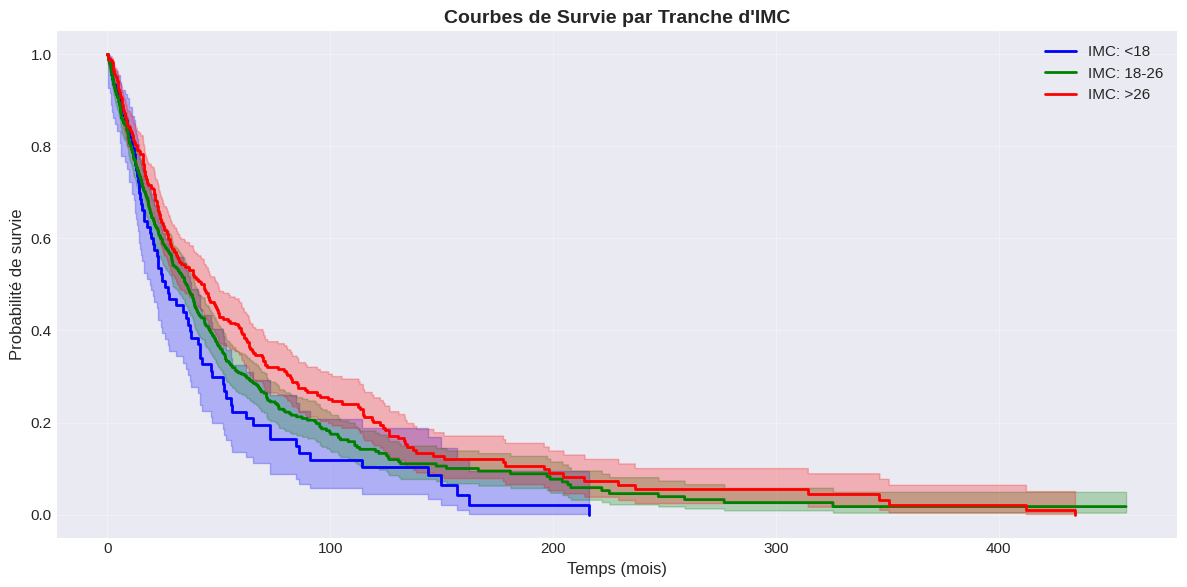


Test du Log-Rank multivarié (IMC):
p-value: 0.0083
Différence significative entre les tranches d'IMC (p < 0.05)


In [ ]:
# Courbes de survie par tranche d'IMC
plt.figure(figsize=(12, 6))

bmi_order = ['<18', '18-26', '>26']
colors_bmi = ['blue', 'green', 'red']

for bmi_group, color in zip(bmi_order, colors_bmi):
    mask = df['Tranche_BMI'] == bmi_group
    if mask.sum() > 0:  # Vérifier qu'il y a des données
        kmf_bmi = KaplanMeierFitter()
        kmf_bmi.fit(durations=df[mask]['Time_to_Event'],
                    event_observed=df[mask]['Event_Observed'],
                    label=f'IMC: {bmi_group}')
        kmf_bmi.plot_survival_function(ci_show=True, linewidth=2, color=color)

        print(f"Tranche d'IMC {bmi_group}:")
        print(f"  Médiane de survie: {kmf_bmi.median_survival_time_:.2f} mois")
        print(f"  Nombre de patients: {mask.sum()}\n")

plt.title('Courbes de Survie par Tranche d\'IMC', fontsize=14, fontweight='bold')
plt.xlabel('Temps (mois)', fontsize=12)
plt.ylabel('Probabilité de survie', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Test multivarié
results_activity = multivariate_logrank_test(
    df['Time_to_Event'],
    df['Tranche_BMI'],
    df['Event_Observed']
)

print(f"\nTest du Log-Rank multivarié (IMC):")
print(f"p-value: {results_activity.p_value:.4f}")
if results_activity.p_value < 0.05:
    print("Différence significative entre les tranches d'IMC (p < 0.05)")
else:
    print("Pas de différence significative entre les tranches d'IMC (p ≥ 0.05)")